In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [17]:
# load saved predictions (no retraining)
data = pd.read_csv(
    "../outputs/data_with_gbdt_predictions.csv",
    parse_dates=["Date"]
)

# standardize column name
data = data.rename(columns={"predicted_return": "predicted_return_gbdt"})

# sort for safety
data = data.sort_values(["Date", "ticker"]).reset_index(drop=True)

# sanity check
assert "predicted_return_gbdt" in data.columns


In [18]:
# rank stocks daily by predicted return
data["pred_rank"] = (
    data.groupby("Date")["predicted_return_gbdt"]
    .rank(ascending=False, method="first")
)

# number of tradable assets per day
data["n_assets"] = data.groupby("Date")["ticker"].transform("count")

# define long / short universe
data["is_long"] = data["pred_rank"] <= 0.2 * data["n_assets"]
data["is_short"] = data["pred_rank"] > 0.8 * data["n_assets"]

# inverse volatility for risk scaling
data["inv_vol"] = 1 / data["vol_10"]

# initialize weights
data["long_weight"] = 0.0
data["short_weight"] = 0.0

# volatility-scaled long weights (sum = +1 per day)
data.loc[data["is_long"], "long_weight"] = (
    data.loc[data["is_long"], "inv_vol"] /
    data.loc[data["is_long"]]
        .groupby("Date")["inv_vol"]
        .transform("sum")
)

# volatility-scaled short weights (sum = −1 per day)
data.loc[data["is_short"], "short_weight"] = (
    - data.loc[data["is_short"], "inv_vol"] /
    data.loc[data["is_short"]]
        .groupby("Date")["inv_vol"]
        .transform("sum")
)

# final base position
data["position_weight_base"] = data["long_weight"] + data["short_weight"]


In [19]:
# daily portfolio return
portfolio_returns_base = (
    data.groupby("Date")
    .apply(lambda x: (x["position_weight_base"] * x["next_day_return"]).sum())
)

# cumulative return
cum_return_base = np.exp(portfolio_returns_base.cumsum())


TIER 1 STARTS HERE — CONFIDENCE WEIGHTING

In [20]:
# confidence = strength of prediction
data["confidence"] = data["predicted_return_gbdt"].abs()


In [21]:
# initialize column
data["long_weight_conf"] = 0.0

# raw confidence × inverse-vol score
data.loc[data["is_long"], "long_weight_conf"] = (
    data.loc[data["is_long"], "inv_vol"] *
    data.loc[data["is_long"], "confidence"]
)

# normalize so long weights sum to +1 per day
data.loc[data["is_long"], "long_weight_conf"] /= (
    data.loc[data["is_long"]]
        .groupby("Date")["long_weight_conf"]
        .transform("sum")
)


In [22]:
# initialize column
data["short_weight_conf"] = 0.0

# raw confidence × inverse-vol score
data.loc[data["is_short"], "short_weight_conf"] = (
    data.loc[data["is_short"], "inv_vol"] *
    data.loc[data["is_short"], "confidence"]
)

# normalize so short weights sum to −1 per day
data.loc[data["is_short"], "short_weight_conf"] /= (
    data.loc[data["is_short"]]
        .groupby("Date")["short_weight_conf"]
        .transform("sum")
)

# apply negative sign for shorts
data.loc[data["is_short"], "short_weight_conf"] *= -1


In [23]:
# combined confidence-weighted position
data["position_weight_conf"] = (
    data["long_weight_conf"] + data["short_weight_conf"]
)


In [24]:
# daily portfolio return
portfolio_returns_conf = (
    data.groupby("Date")
    .apply(lambda x: (x["position_weight_conf"] * x["next_day_return"]).sum())
)

# cumulative return
cum_return_conf = np.exp(portfolio_returns_conf.cumsum())


In [25]:
# should be ~ +1
print("Long sum:", data.groupby("Date")["long_weight_conf"].sum().describe())

# should be ~ −1
print("Short sum:", data.groupby("Date")["short_weight_conf"].sum().describe())

# should be ~ 0
print("Net exposure:", data.groupby("Date")["position_weight_conf"].sum().describe())


Long sum: count    2500.000000
mean        0.899200
std         0.301124
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: long_weight_conf, dtype: float64
Short sum: count    2500.000000
mean       -0.899200
std         0.301124
min        -1.000000
25%        -1.000000
50%        -1.000000
75%        -1.000000
max         0.000000
Name: short_weight_conf, dtype: float64
Net exposure: count    2.500000e+03
mean     2.382339e-18
std      6.854663e-17
min     -2.359224e-16
25%     -4.163336e-17
50%      0.000000e+00
75%      4.857226e-17
max      2.359224e-16
Name: position_weight_conf, dtype: float64


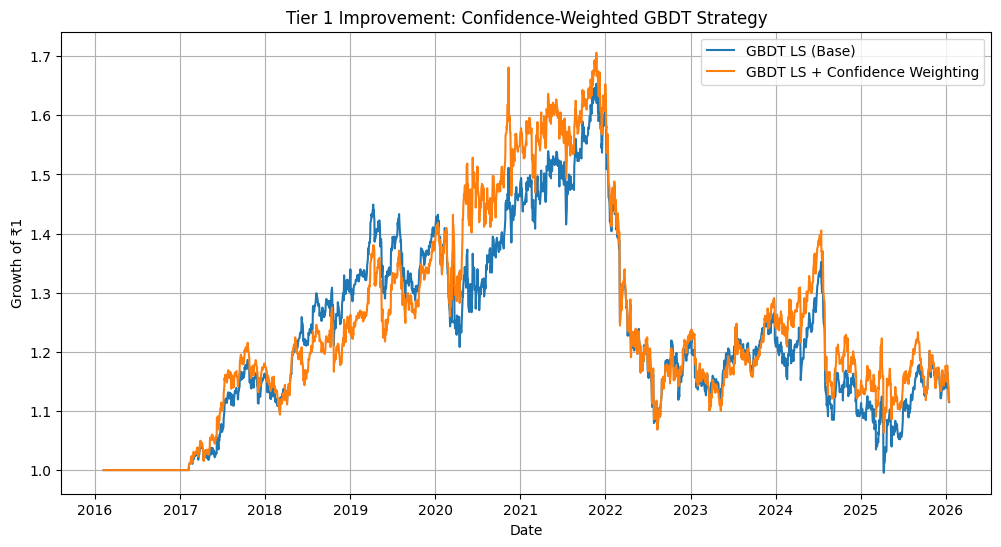

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(cum_return_base, label="GBDT LS (Base)")
plt.plot(cum_return_conf, label="GBDT LS + Confidence Weighting")

plt.title("Tier 1 Improvement: Confidence-Weighted GBDT Strategy")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")
plt.legend()
plt.grid(True)
plt.show()


TIER 2a — MARKET RISK-OFF FILTER (CRASH PROTECTION)
